In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -------------------------------
# 1. LOAD PREPROCESSED UNSCALED DATA
# -------------------------------
train_path = "../data/white_wine_train_unscaled.csv"
test_path = "../data/white_wine_test_unscaled.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("===== DATA LOADING =====")
print("Train dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nFirst 5 rows of training data:")
print(train_df.head())


===== DATA LOADING =====
Train dataset shape: (3168, 12)
Test dataset shape: (793, 12)

First 5 rows of training data:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.1              0.45         0.24             2.7      0.040   
1            6.2              0.24         0.28            12.2      0.049   
2            6.6              0.35         0.35             6.0      0.063   
3            6.4              0.38         0.19             4.5      0.038   
4            6.6              0.25         0.36             8.1      0.045   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 24.0                  87.0  0.98862  2.94       0.38   
1                 54.0                 133.0  0.99520  3.19       0.37   
2                 31.0                 150.0  0.99537  3.10       0.47   
3                 36.0                 119.0  0.99151  3.07       0.42   
4                 54.0                 180

In [2]:
# -------------------------------
# 2. SEPARATE FEATURES (X) AND TARGET (y)
# -------------------------------
X_train = train_df.drop(columns=["quality_label"])
y_train = train_df["quality_label"]

X_test = test_df.drop(columns=["quality_label"])
y_test = test_df["quality_label"]

print("\n===== FEATURES AND TARGET =====")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


===== FEATURES AND TARGET =====
X_train shape: (3168, 11)
y_train shape: (3168,)
X_test shape: (793, 11)
y_test shape: (793,)


In [3]:
# -------------------------------
# 3. TRAIN RANDOM FOREST MODEL
# -------------------------------
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

print("\nRandom Forest model trained successfully.")



Random Forest model trained successfully.


In [4]:
# -------------------------------
# 4. MAKE PREDICTIONS
# -------------------------------
y_pred = model.predict(X_test)

print("\nFirst 10 predictions:")
print(y_pred[:10])


First 10 predictions:
[1 1 1 1 1 1 1 1 1 1]


In [5]:
# -------------------------------
# 5. EVALUATE THE MODEL
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n===== RANDOM FOREST RESULTS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



===== RANDOM FOREST RESULTS =====
Accuracy  : 0.7516
Precision : 0.8007
Recall    : 0.8298
F1-Score  : 0.8150

Confusion Matrix:
[[162 108]
 [ 89 434]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.60      0.62       270
           1       0.80      0.83      0.82       523

    accuracy                           0.75       793
   macro avg       0.72      0.71      0.72       793
weighted avg       0.75      0.75      0.75       793



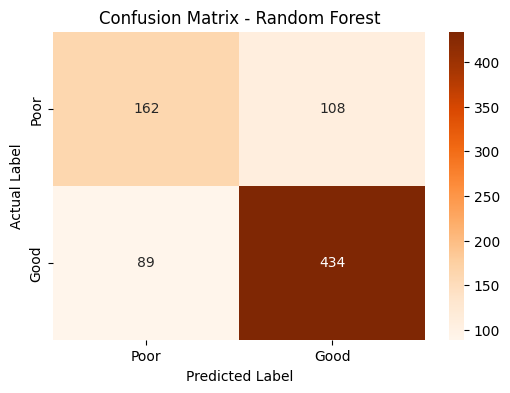

In [6]:
# -------------------------------
# 6. PLOT CONFUSION MATRIX
# -------------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Poor", "Good"],
    yticklabels=["Poor", "Good"]
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()